In [1]:
from gstatot import sweep_utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

sns.set_style('ticks')
sns.set_context('paper', font_scale=1.5)

In [2]:
results_dir = f'./sweep_res/integrated_T_sweep'
os.makedirs('./sweep_res/final_figures', exist_ok=True)
results_files = glob.glob(f'{results_dir}/*.csv')
pre_res = pd.DataFrame()
post_res = pd.DataFrame()
for f in results_files:
    if 'prenatal' in f:
        pre_res = pd.concat([pre_res, pd.read_csv(f, index_col=0)], ignore_index=True) 
    elif 'postnatal' in f:
        post_res = pd.concat([post_res, pd.read_csv(f, index_col=0)], ignore_index=True)

In [3]:
# # reweight mean metrics
pre_res['mean_metric'] = (2/4 * (pre_res['marginal_W2_dist'] - np.nanmin(pre_res['marginal_W2_dist']))/ (np.nanmax(pre_res['marginal_W2_dist']) - np.nanmin(pre_res['marginal_W2_dist'])) +
                          1/4 * (pre_res['traj_W2_dist'] - np.nanmin(pre_res['traj_W2_dist']))/(np.nanmax(pre_res['traj_W2_dist']) - np.nanmin(pre_res['traj_W2_dist'])) + 
                          1/4 * (pre_res['FP_TV_dist'] - np.nanmin(pre_res['FP_TV_dist']))/(np.nanmax(pre_res['FP_TV_dist']) - np.nanmin(pre_res['FP_TV_dist']))
)
post_res['mean_metric'] = (2/4 * (post_res['marginal_W2_dist'] - np.nanmin(post_res['marginal_W2_dist']))/ (np.nanmax(post_res['marginal_W2_dist']) - np.nanmin(post_res['marginal_W2_dist'])) +
                          1/4 * (post_res['traj_W2_dist'] - np.nanmin(post_res['traj_W2_dist']))/(np.nanmax(post_res['traj_W2_dist']) - np.nanmin(post_res['traj_W2_dist'])) + 
                          1/4 * (post_res['FP_TV_dist'] - np.nanmin(post_res['FP_TV_dist']))/(np.nanmax(post_res['FP_TV_dist']) - np.nanmin(post_res['FP_TV_dist']))
)
                          

In [4]:
gsot_cmap = sns.color_palette("Blues", as_cmap=True)
sot_cmap = sns.color_palette("Purples", as_cmap=True)
pba_cmap = sns.color_palette("Greens", as_cmap=True)

figsize = 4

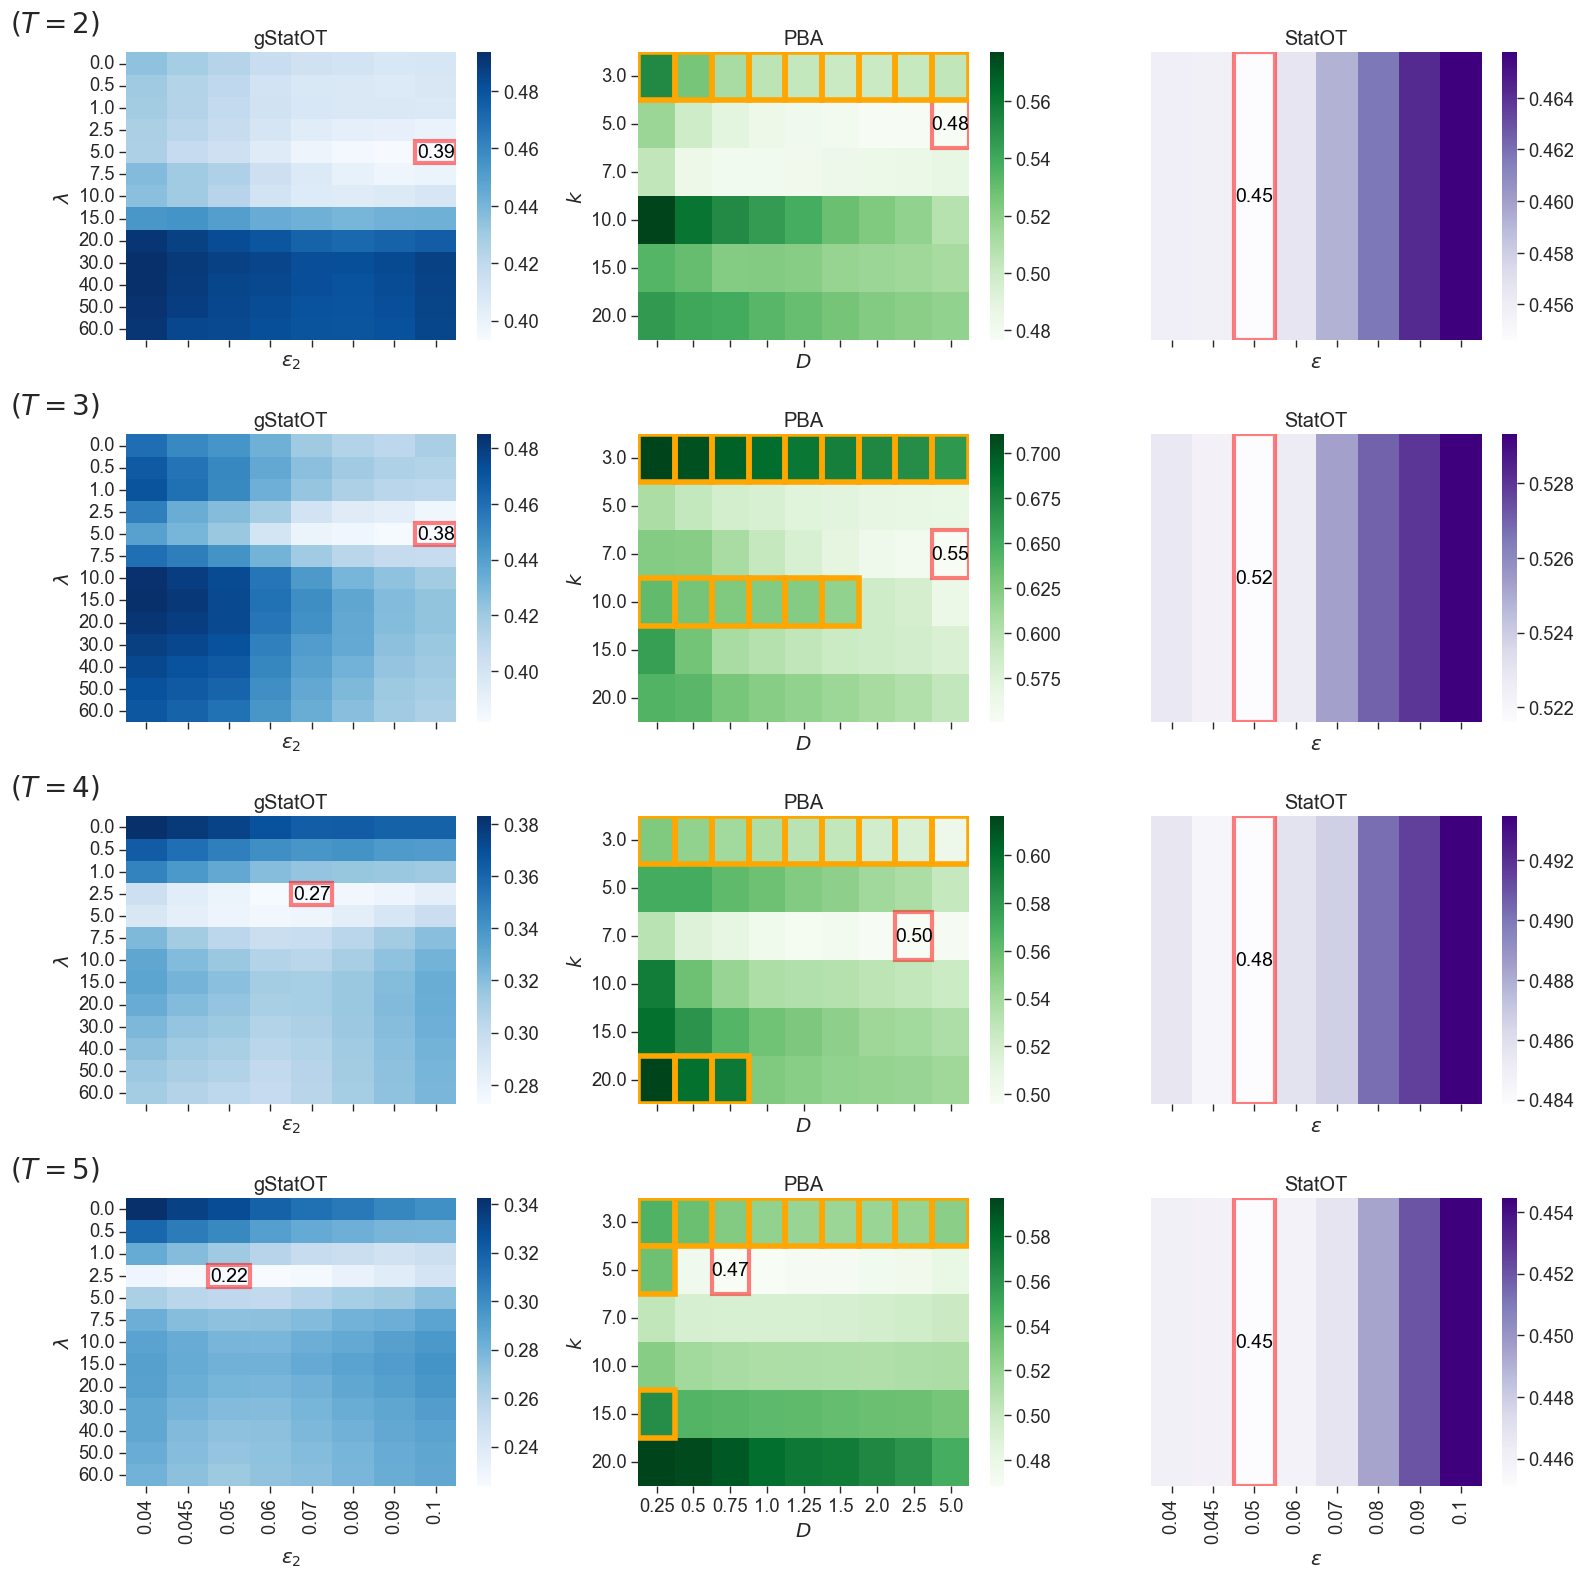

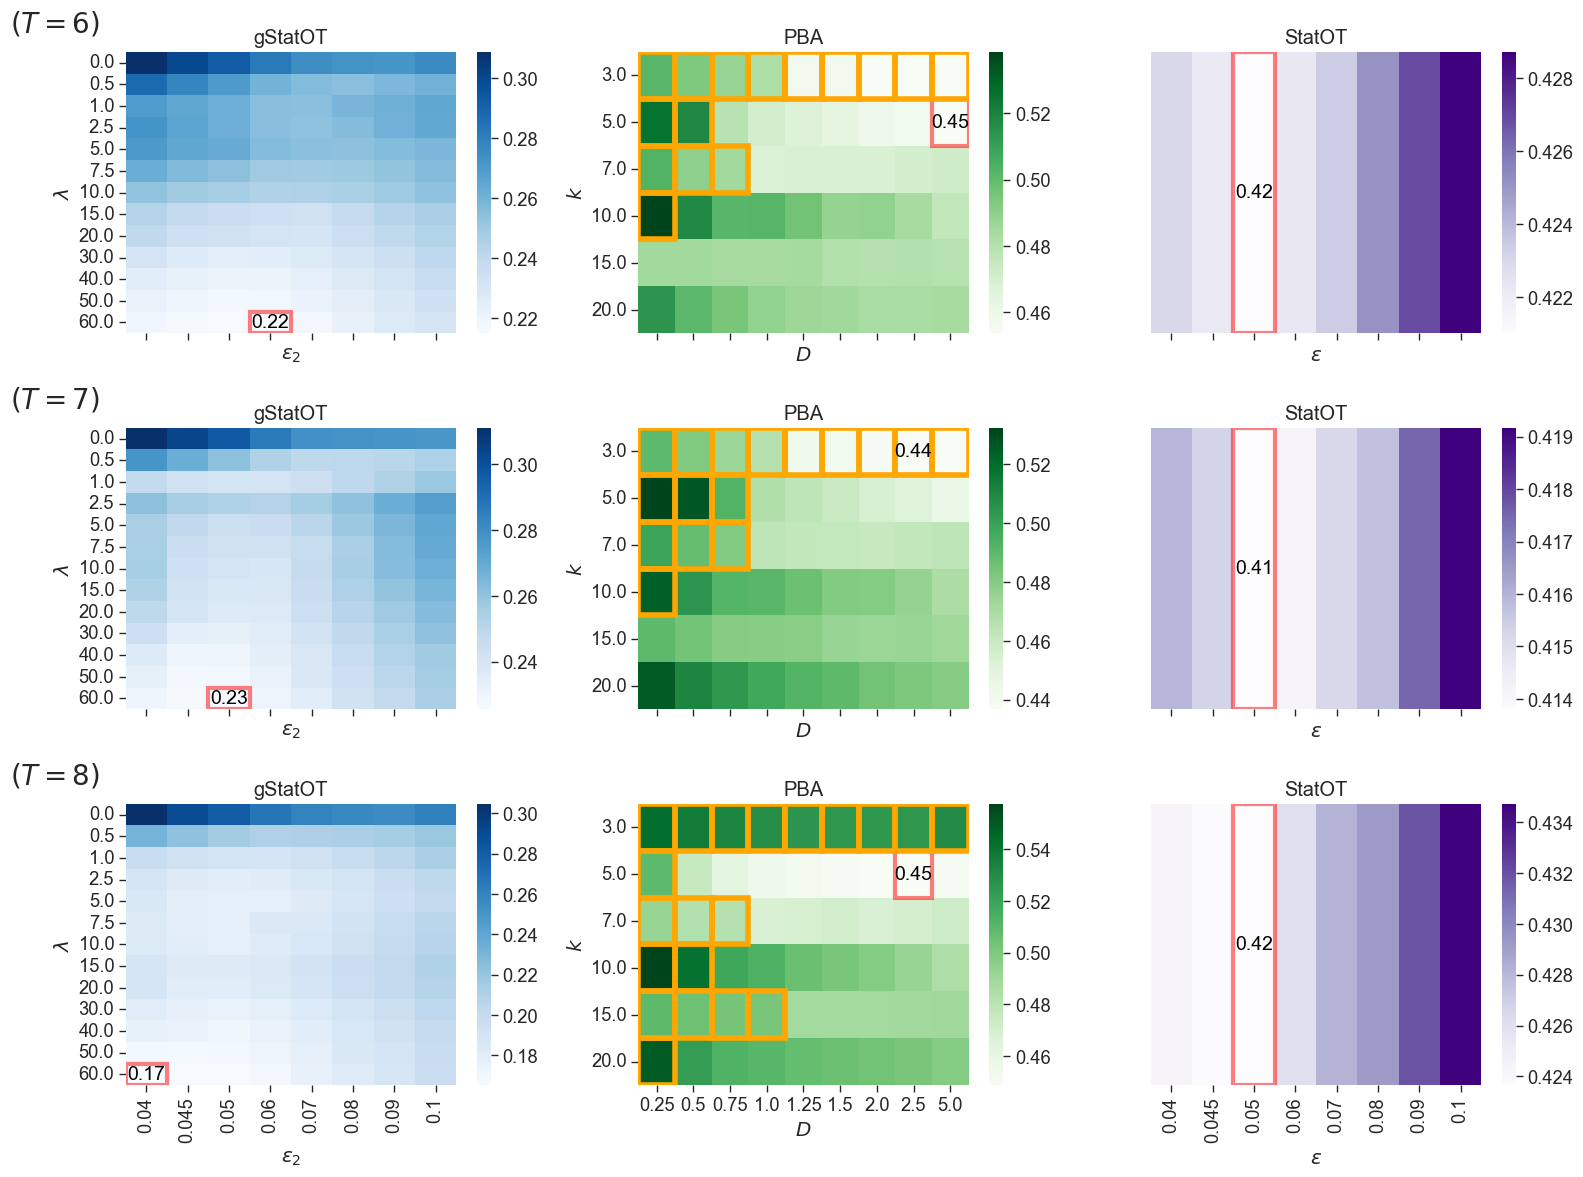

In [5]:
T_vals = pre_res['T'].unique()
T_vals.sort()

gStatOT_opt_vals = {}
StatOT_opt_vals = {}
PBA_opt_vals = {}

fig, axs = plt.subplots(4, 3, figsize=(figsize * 4, figsize * 4), sharex='col', )
for i, T in enumerate(T_vals[:4]):

    res_T = pre_res[pre_res['T'] == T].copy()
    res_df_gStatOT = res_T[res_T['method'] == 'gStatOT']
    res_df_StatOT = res_T[res_T['method'] == 'StatOT']
    res_df_PBA = res_T[res_T['method'] == 'PBA']

    ax1 = axs[i, 0] 
    vmin = None
    vmax = None
    lam, epsilon2 = sweep_utils.plot_sweep_results(res_df_gStatOT, 'lam', 'epsilon2', 
                                         metric='mean_metric', title='gStatOT',  
                                         cbar=True,
                                         input_ax=ax1,
                                         vminmax=(vmin, vmax),
                                         highlight_nans=True,
                                         cmap=gsot_cmap)
    ax1.set_ylabel(r'$\lambda$')
    ax1.set_xlabel(r'$\epsilon_2$')

    # add T as text to the left of the row
    ax1.text(-0.35, 1.1, rf'$(T={T})$', transform=ax1.transAxes, fontsize=20, 
             fontweight='bold', va='center')

    gStatOT_opt_vals[T] = (lam, epsilon2)


    ax3 = axs[i, 2]
    _, epsilon = sweep_utils.plot_sweep_results(res_df_StatOT, None, 'epsilon',
                                         metric='mean_metric', title='StatOT',
                                         cbar=True,
                                         input_ax=ax3,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=sot_cmap)
    ax3.set_xlabel(r'$\epsilon$')
    ax3.set_ylabel('')
    ax3.set_yticks([])
    StatOT_opt_vals[T] = epsilon

    ax2 = axs[i, 1]
    k, D= sweep_utils.plot_sweep_results(res_df_PBA, 'k', 'D',
                                         metric='mean_metric', title='PBA',
                                         cbar=True,
                                         input_ax=ax2,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=pba_cmap)
    ax2.set_xlabel(r'$D$')
    ax2.set_ylabel(r'$k$')
    ax2.tick_params(axis='y', rotation=0)
    PBA_opt_vals[T] = (k, D)

plt.tight_layout()
plt.savefig(f'./sweep_res/final_figures/prenatal_results_T={T_vals[0]}-{T_vals[3]}.png', dpi=350)

fig, axs = plt.subplots(3, 3, figsize=(figsize * 4, figsize * 3), sharex='col')

for i, T in enumerate(T_vals[4:]):

    res_T = pre_res[pre_res['T'] == T].copy()
    vmin = None 
    vmax = None 
    res_df_gStatOT = res_T[res_T['method'] == 'gStatOT']
    res_df_StatOT = res_T[res_T['method'] == 'StatOT']
    res_df_PBA = res_T[res_T['method'] == 'PBA']

    ax1 = axs[i, 0] 
    lam, epsilon2 = sweep_utils.plot_sweep_results(res_df_gStatOT, 'lam', 'epsilon2', 
                                         metric='mean_metric', title='gStatOT',  
                                         cbar=True,
                                         input_ax=ax1,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=gsot_cmap)
    ax1.set_ylabel(r'$\lambda$')
    ax1.set_xlabel(r'$\epsilon_2$')

    # add T as text to the left of the row
    ax1.text(-0.35, 1.1, rf'$(T={T})$', transform=ax1.transAxes, fontsize=20, 
             fontweight='bold', va='center')

    gStatOT_opt_vals[T] = (lam, epsilon2)


    ax3 = axs[i, 2]
    _, epsilon = sweep_utils.plot_sweep_results(res_df_StatOT, None, 'epsilon',
                                         metric='mean_metric', title='StatOT',
                                         cbar=True,
                                         input_ax=ax3,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=sot_cmap)
    ax3.set_xlabel(r'$\epsilon$')
    ax3.set_ylabel('')
    ax3.set_yticks([])
    StatOT_opt_vals[T] = epsilon

    ax2 = axs[i, 1]
    k, D= sweep_utils.plot_sweep_results(res_df_PBA, 'k', 'D',
                                         metric='mean_metric', title='PBA',
                                         cbar=True,
                                         input_ax=ax2,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=pba_cmap)
    ax2.set_xlabel(r'$D$')
    ax2.set_ylabel(r'$k$')
    ax2.tick_params(axis='y', rotation=0)
    PBA_opt_vals[T] = (k, D)

plt.tight_layout()
plt.savefig(f'./sweep_res/final_figures/prenatal_results_T={T_vals[4]}-{T_vals[-1]}.png', dpi=350)
plt.show()
gStatOT_opt_vals_df = pd.DataFrame(gStatOT_opt_vals, index=['lam', 'epsilon2']).T
StatOT_opt_vals_df = pd.DataFrame(StatOT_opt_vals, index=['epsilon']).T
PBA_opt_vals_df = pd.DataFrame(PBA_opt_vals, index=['k', 'D']).T

gStatOT_opt_vals_df.to_csv('./gStatOT_opt_vals_prenatal.csv')
StatOT_opt_vals_df.to_csv('./StatOT_opt_vals_prenatal.csv')
PBA_opt_vals_df.to_csv('./PBA_opt_vals_prenatal.csv')

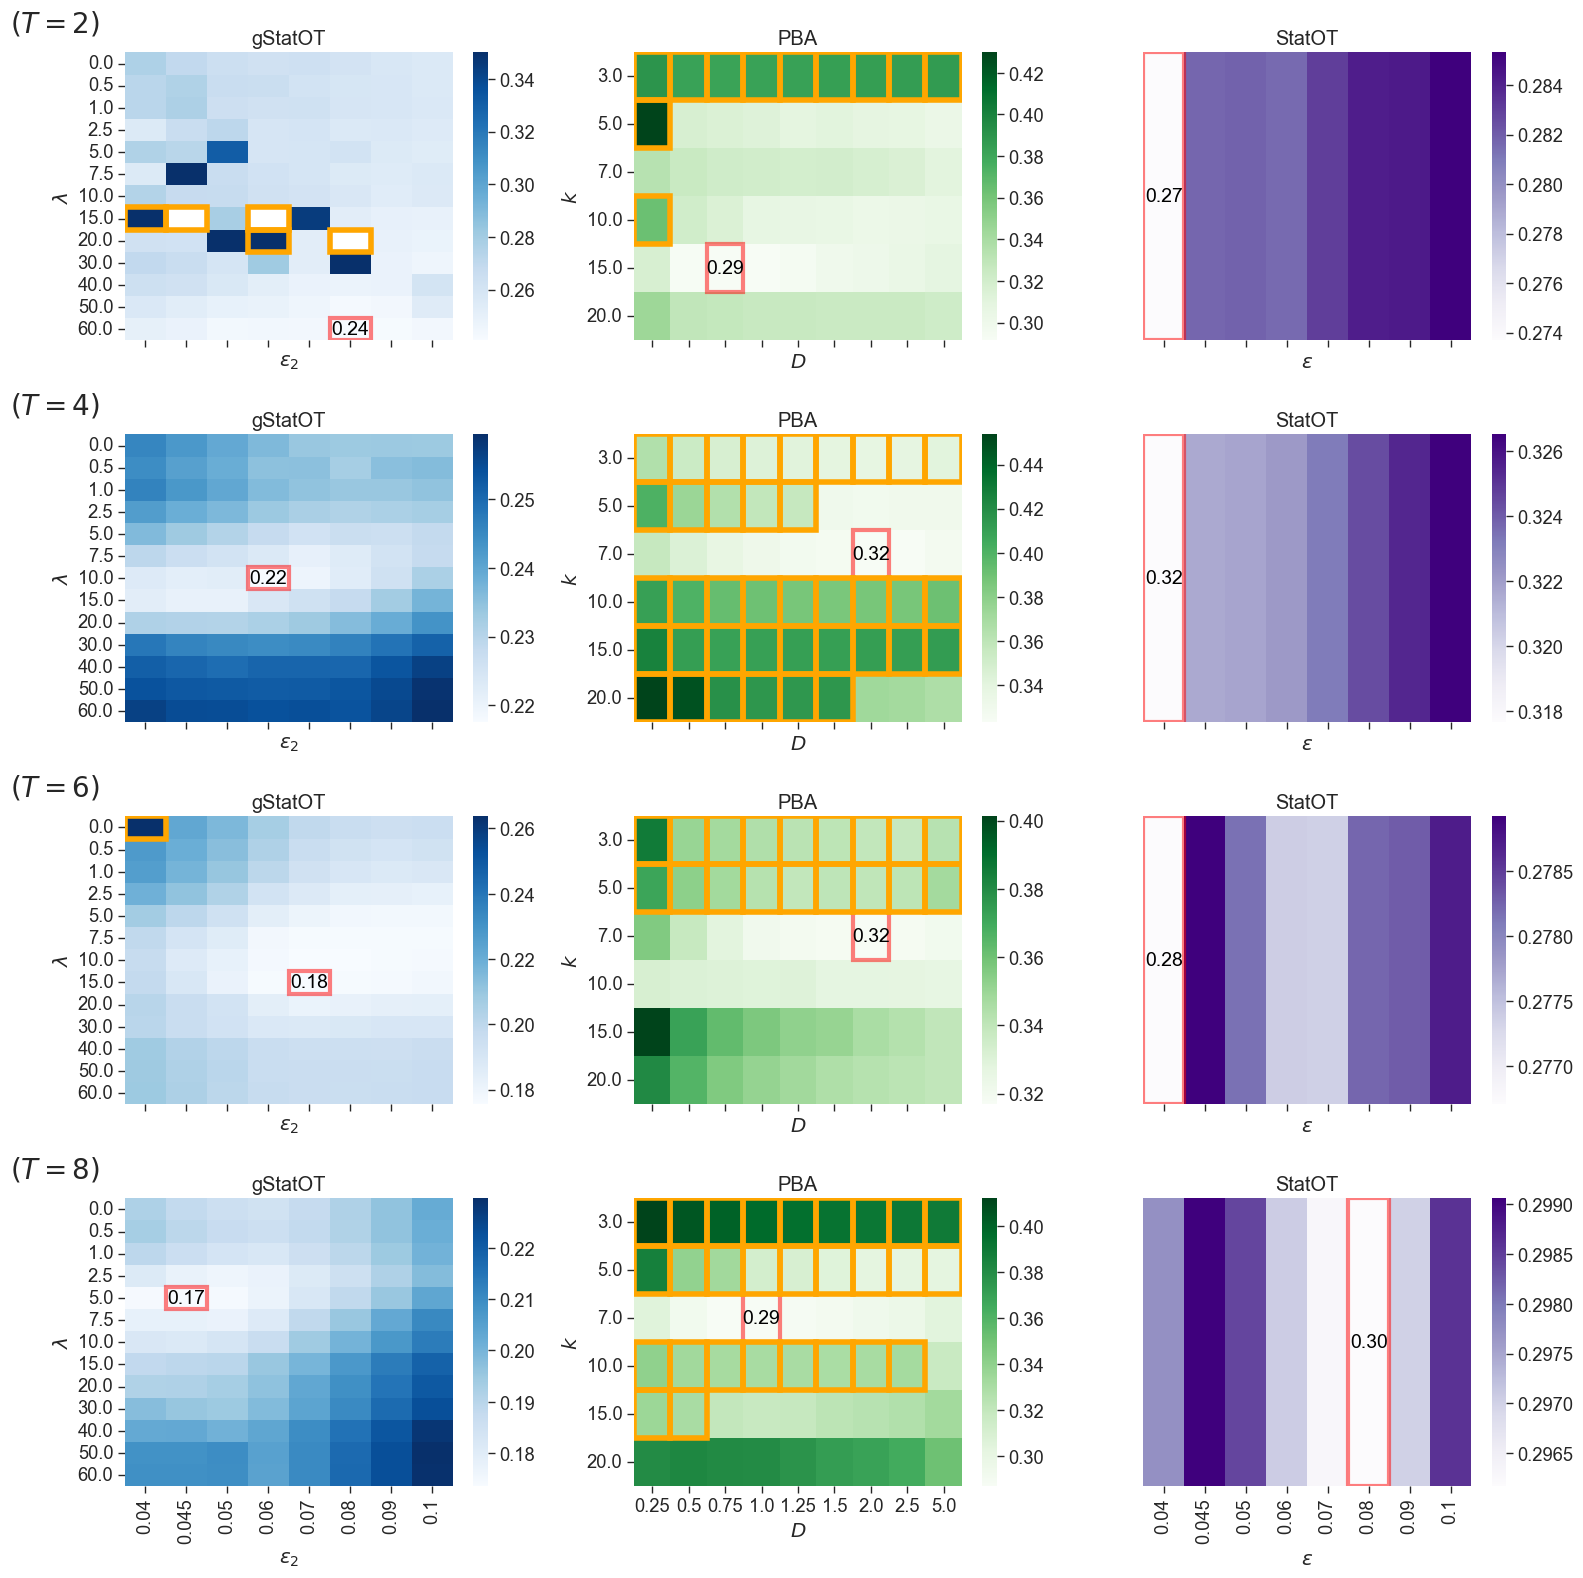

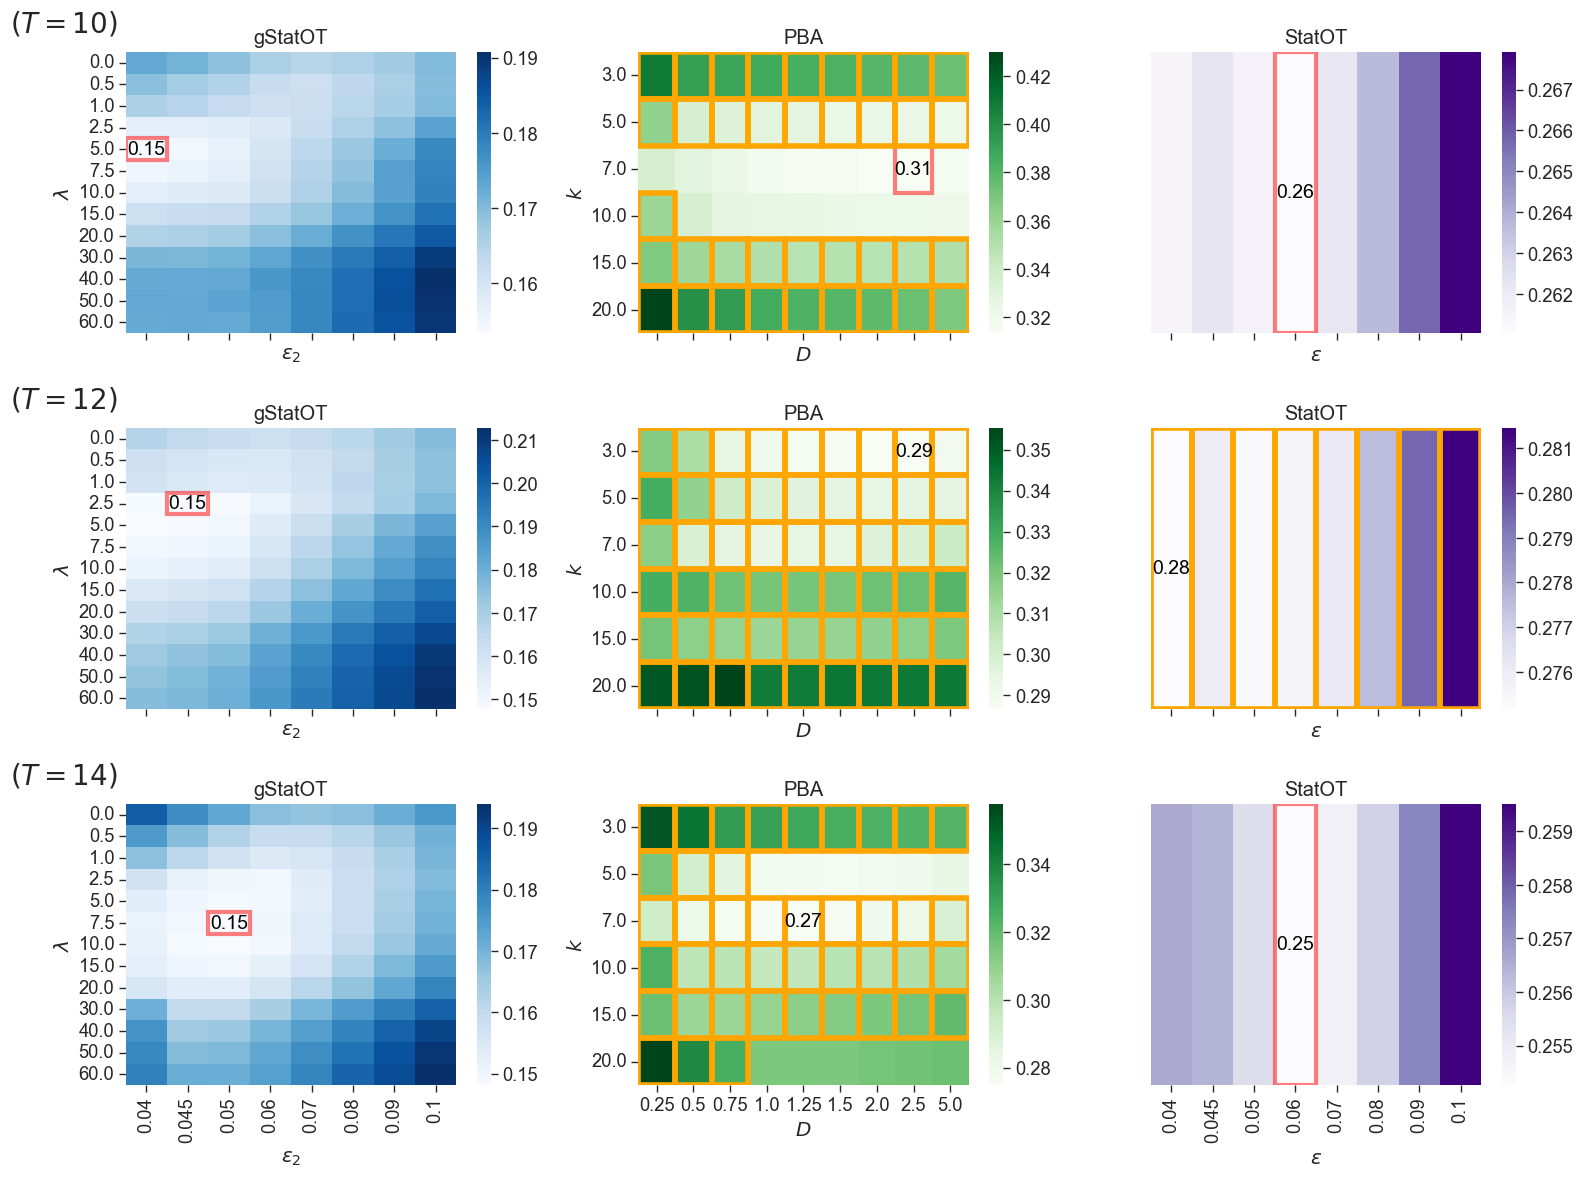

In [6]:
T_vals = post_res['T'].unique()
T_vals.sort()

gStatOT_opt_vals = {}
StatOT_opt_vals = {}
PBA_opt_vals = {}

fig, axs = plt.subplots(4, 3, figsize=(figsize * 4, figsize * len(T_vals[:4])), sharex='col', )
for i, T in enumerate(T_vals[:4]):

    res_T = post_res[post_res['T'] == T].copy()
    res_df_gStatOT = res_T[res_T['method'] == 'gStatOT']
    res_df_StatOT = res_T[res_T['method'] == 'StatOT']
    res_df_PBA = res_T[res_T['method'] == 'PBA']

    ax1 = axs[i, 0] 
    vmin = None
    vmax = None
    lam, epsilon2 = sweep_utils.plot_sweep_results(res_df_gStatOT, 'lam', 'epsilon2', 
                                         metric='mean_metric', title='gStatOT',  
                                         cbar=True,
                                         input_ax=ax1,
                                         vminmax=(vmin, vmax) if i != 0 else (None, 0.35),
                                         highlight_nans=True,
                                         cmap=gsot_cmap)
    ax1.set_ylabel(r'$\lambda$')
    ax1.set_xlabel(r'$\epsilon_2$')

    # add T as text to the left of the row
    ax1.text(-0.35, 1.1, rf'$(T={T})$', transform=ax1.transAxes, fontsize=20, 
             fontweight='bold', va='center')

    gStatOT_opt_vals[T] = (lam, epsilon2)


    ax3 = axs[i, 2]
    _, epsilon = sweep_utils.plot_sweep_results(res_df_StatOT, None, 'epsilon',
                                         metric='mean_metric', title='StatOT',
                                         cbar=True,
                                         input_ax=ax3,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=sot_cmap)
    ax3.set_xlabel(r'$\epsilon$')
    ax3.set_ylabel('')
    ax3.set_yticks([])
    StatOT_opt_vals[T] = epsilon

    ax2 = axs[i, 1]
    k, D= sweep_utils.plot_sweep_results(res_df_PBA, 'k', 'D',
                                         metric='mean_metric', title='PBA',
                                         cbar=True,
                                         input_ax=ax2,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=pba_cmap)
    ax2.set_xlabel(r'$D$')
    ax2.set_ylabel(r'$k$')
    ax2.tick_params(axis='y', rotation=0)
    PBA_opt_vals[T] = (k, D)

plt.tight_layout()
plt.savefig(f'./sweep_res/final_figures/postnatal_results_T={T_vals[0]}-{T_vals[3]}.png', dpi=350)

fig, axs = plt.subplots(3, 3, figsize=(figsize * 4, figsize * 3), sharex='col')

for i, T in enumerate(T_vals[4:]):

    res_T = post_res[post_res['T'] == T].copy()
    vmin = None 
    vmax = None 
    res_df_gStatOT = res_T[res_T['method'] == 'gStatOT']
    res_df_StatOT = res_T[res_T['method'] == 'StatOT']
    res_df_PBA = res_T[res_T['method'] == 'PBA']

    ax1 = axs[i, 0] 
    lam, epsilon2 = sweep_utils.plot_sweep_results(res_df_gStatOT, 'lam', 'epsilon2', 
                                         metric='mean_metric', title='gStatOT',  
                                         cbar=True,
                                         input_ax=ax1,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=gsot_cmap)
    ax1.set_ylabel(r'$\lambda$')
    ax1.set_xlabel(r'$\epsilon_2$')

    # add T as text to the left of the row
    ax1.text(-0.35, 1.1, rf'$(T={T})$', transform=ax1.transAxes, fontsize=20, 
             fontweight='bold', va='center')

    gStatOT_opt_vals[T] = (lam, epsilon2)


    ax3 = axs[i, 2]
    _, epsilon = sweep_utils.plot_sweep_results(res_df_StatOT, None, 'epsilon',
                                         metric='mean_metric', title='StatOT',
                                         cbar=True,
                                         input_ax=ax3,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=sot_cmap)
    ax3.set_xlabel(r'$\epsilon$')
    ax3.set_ylabel('')
    ax3.set_yticks([])
    StatOT_opt_vals[T] = epsilon

    ax2 = axs[i, 1]
    k, D= sweep_utils.plot_sweep_results(res_df_PBA, 'k', 'D',
                                         metric='mean_metric', title='PBA',
                                         cbar=True,
                                         input_ax=ax2,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=pba_cmap)
    ax2.set_xlabel(r'$D$')
    ax2.set_ylabel(r'$k$')
    ax2.tick_params(axis='y', rotation=0)
    PBA_opt_vals[T] = (k, D)

plt.tight_layout()
plt.savefig(f'./sweep_res/final_figures/postnatal_results_T={T_vals[4]}-{T_vals[-1]}.png', dpi=350)
plt.show()
gStatOT_opt_vals_df = pd.DataFrame(gStatOT_opt_vals, index=['lam', 'epsilon2']).T
StatOT_opt_vals_df = pd.DataFrame(StatOT_opt_vals, index=['epsilon']).T
PBA_opt_vals_df = pd.DataFrame(PBA_opt_vals, index=['k', 'D']).T

gStatOT_opt_vals_df.to_csv('./gStatOT_opt_vals_postnatal.csv')
StatOT_opt_vals_df.to_csv('./StatOT_opt_vals_postnatal.csv')
PBA_opt_vals_df.to_csv('./PBA_opt_vals_postnatal.csv')

In [7]:
results_dir = f'./sweep_res/integrated_n_sweep'
results_files = glob.glob(f'{results_dir}/*.csv')
pre_res = pd.DataFrame()
post_res = pd.DataFrame()
for f in results_files:
    if 'prenatal' in f:
        pre_res = pd.concat([pre_res, pd.read_csv(f, index_col=0)], ignore_index=True) 
    elif 'postnatal' in f:
        post_res = pd.concat([post_res, pd.read_csv(f, index_col=0)], ignore_index=True)

In [8]:
# # reweight mean metrics
pre_res['mean_metric'] = (2/4 * (pre_res['marginal_W2_dist'] - np.nanmin(pre_res['marginal_W2_dist']))/ (np.nanmax(pre_res['marginal_W2_dist']) - np.nanmin(pre_res['marginal_W2_dist'])) +
                          1/4 * (pre_res['traj_W2_dist'] - np.nanmin(pre_res['traj_W2_dist']))/(np.nanmax(pre_res['traj_W2_dist']) - np.nanmin(pre_res['traj_W2_dist'])) + 
                          1/4 * (pre_res['FP_TV_dist'] - np.nanmin(pre_res['FP_TV_dist']))/(np.nanmax(pre_res['FP_TV_dist']) - np.nanmin(pre_res['FP_TV_dist']))
)
post_res['mean_metric'] = (2/4 * (post_res['marginal_W2_dist'] - np.nanmin(post_res['marginal_W2_dist']))/ (np.nanmax(post_res['marginal_W2_dist']) - np.nanmin(post_res['marginal_W2_dist'])) +
                          1/4 * (post_res['traj_W2_dist'] - np.nanmin(post_res['traj_W2_dist']))/(np.nanmax(post_res['traj_W2_dist']) - np.nanmin(post_res['traj_W2_dist'])) + 
                          1/4 * (post_res['FP_TV_dist'] - np.nanmin(post_res['FP_TV_dist']))/(np.nanmax(post_res['FP_TV_dist']) - np.nanmin(post_res['FP_TV_dist']))
)

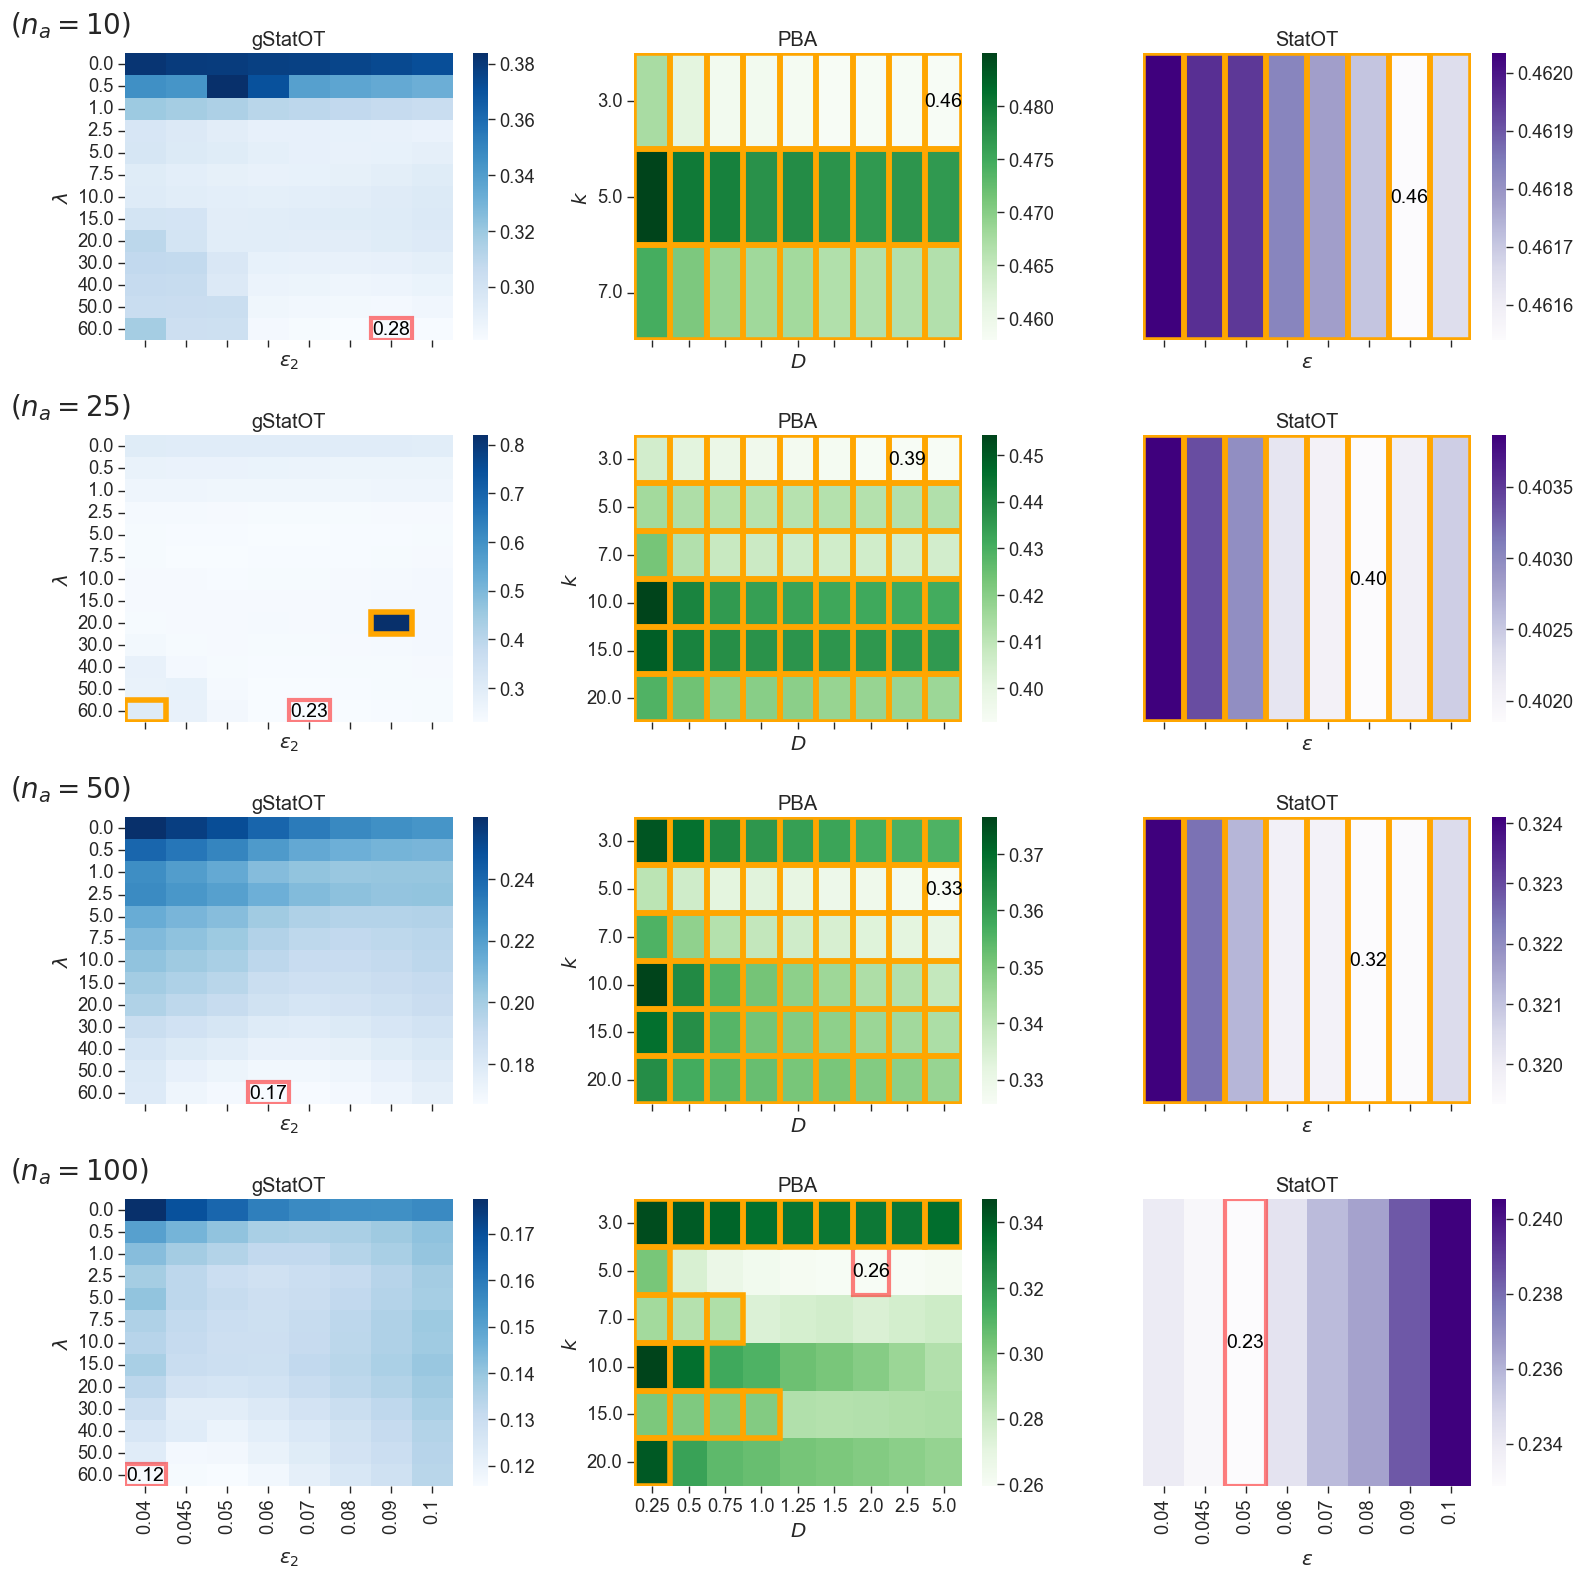

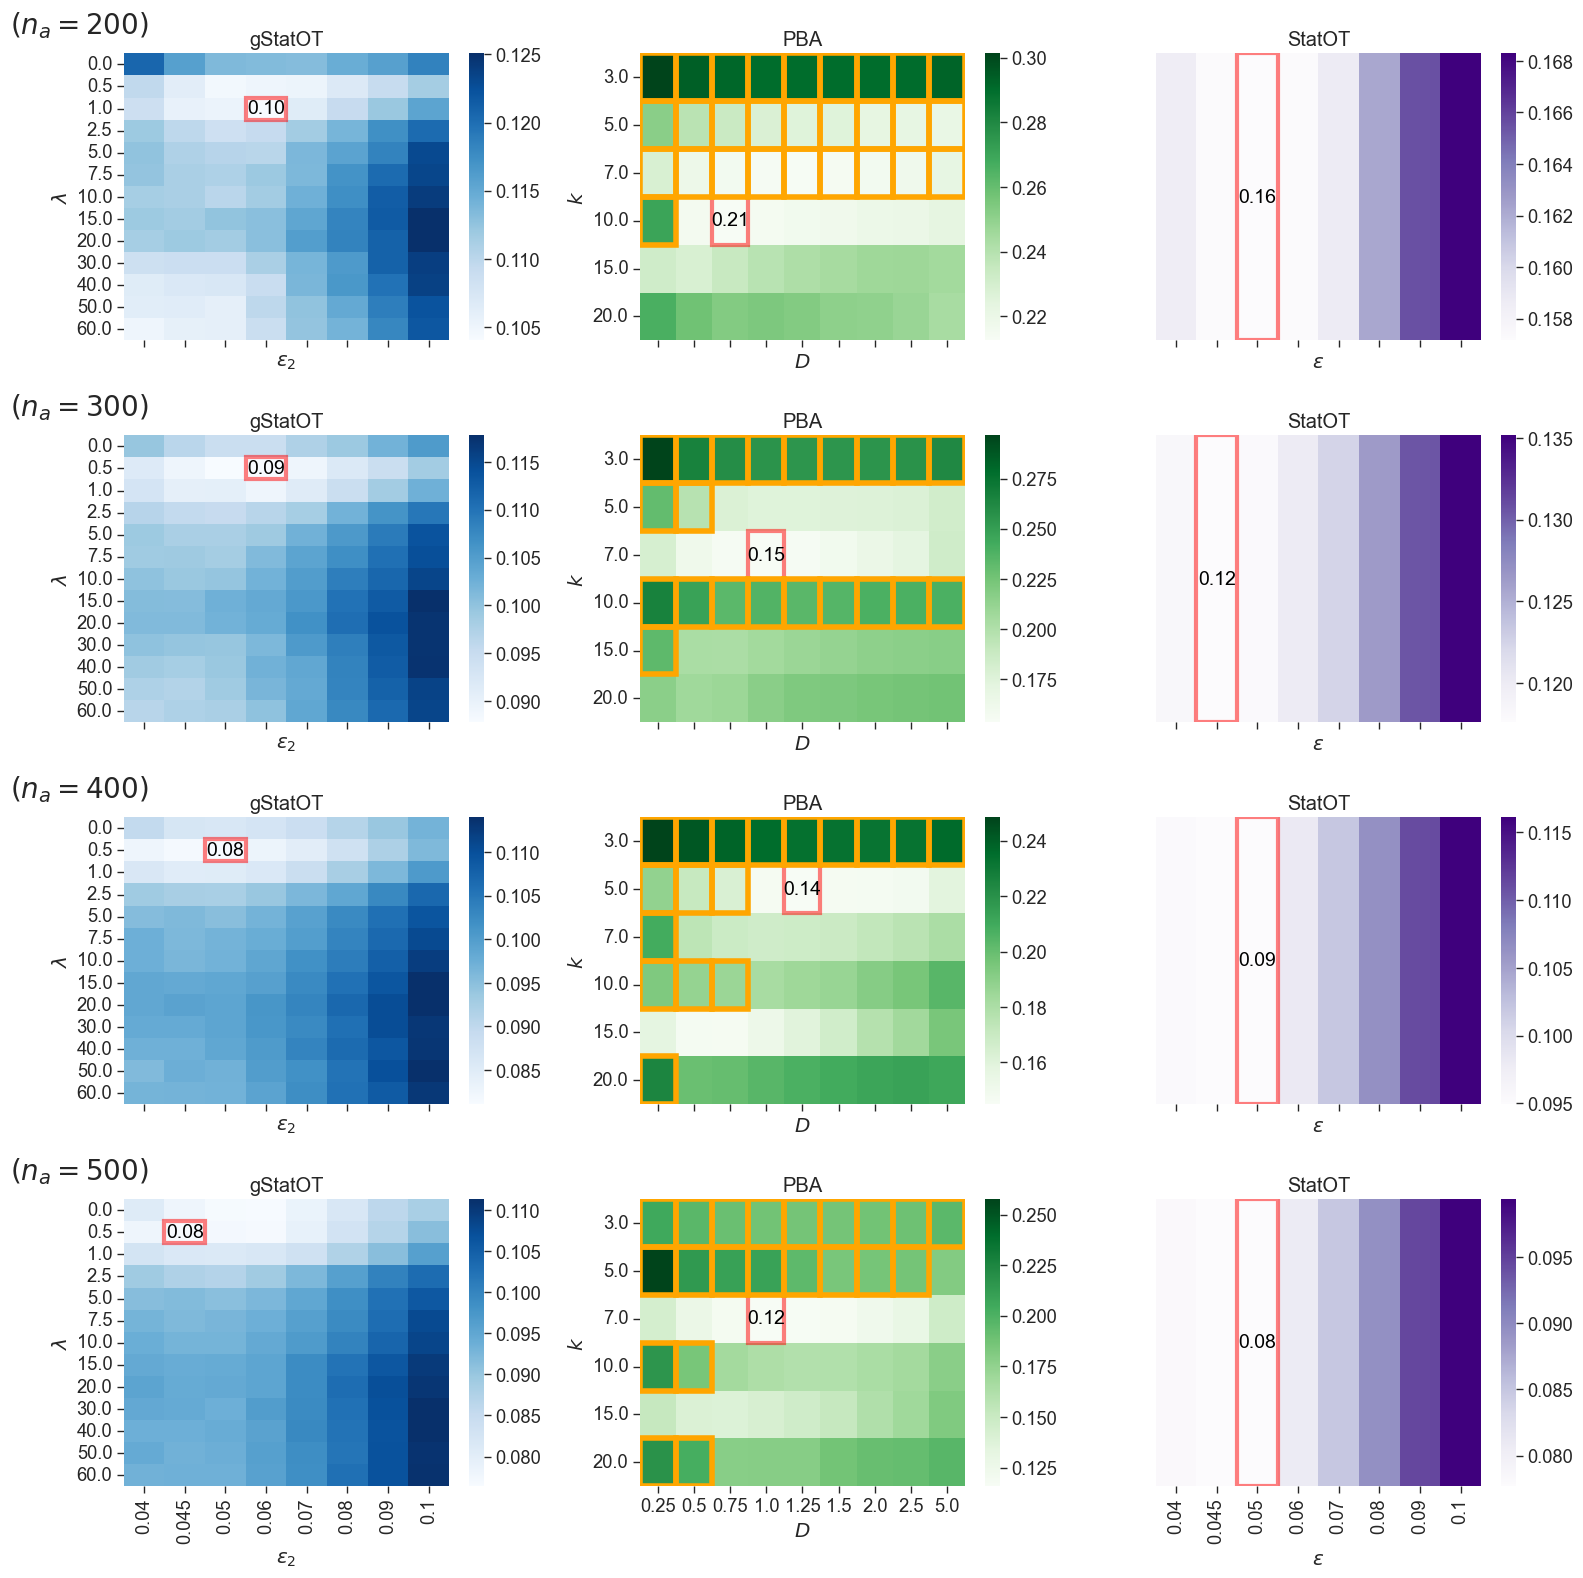

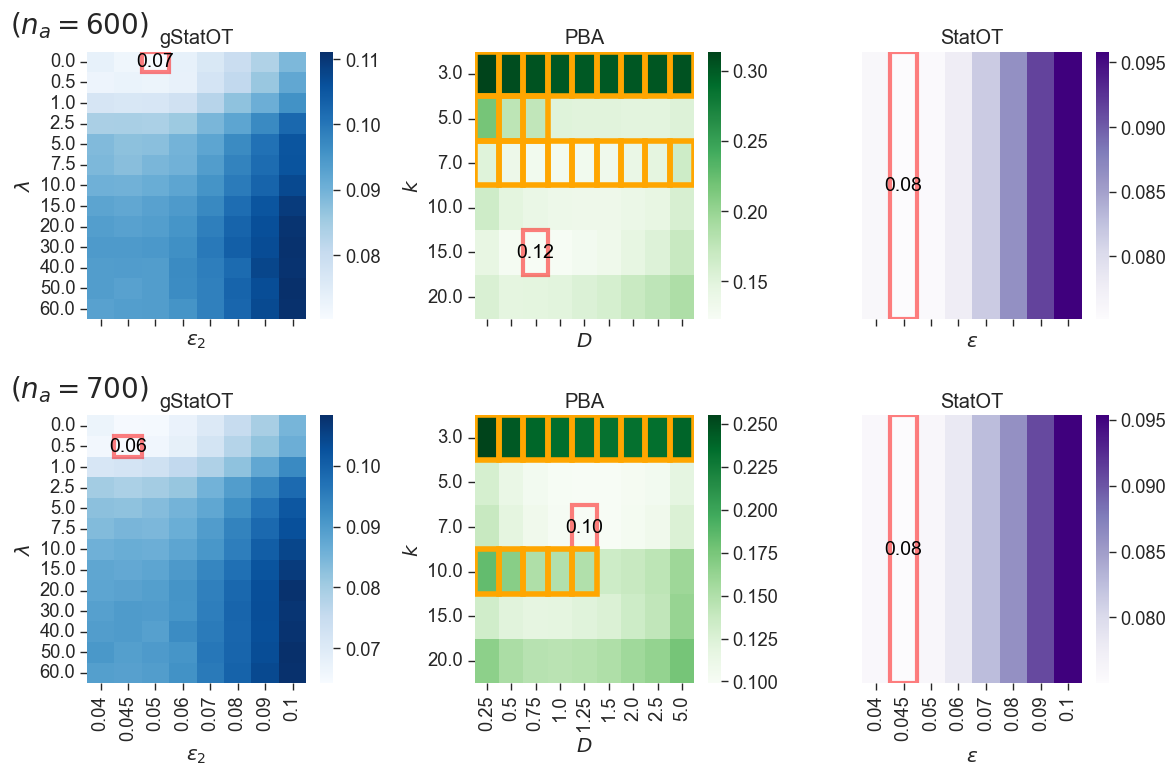

In [9]:
n_vals = pre_res['n'].unique()
n_vals.sort()

gStatOT_opt_vals = {}
StatOT_opt_vals = {}
PBA_opt_vals = {}

fig, axs = plt.subplots(4, 3, figsize=(figsize * 4, figsize * 4), sharex='col', )
for i, n in enumerate(n_vals[:4]):

    res_n = pre_res[pre_res['n'] == n].copy()
    res_df_gStatOT = res_n[res_n['method'] == 'gStatOT']
    res_df_StatOT = res_n[res_n['method'] == 'StatOT']
    res_df_PBA = res_n[res_n['method'] == 'PBA']

    ax1 = axs[i, 0] 
    vmin = None
    vmax = None
    lam, epsilon2 = sweep_utils.plot_sweep_results(res_df_gStatOT, 'lam', 'epsilon2', 
                                         metric='mean_metric', title='gStatOT',  
                                         cbar=True,
                                         input_ax=ax1,
                                         vminmax=(vmin, vmax),
                                         highlight_nans=True,
                                         cmap=gsot_cmap)
    ax1.set_ylabel(r'$\lambda$')
    ax1.set_xlabel(r'$\epsilon_2$')

    ax1.text(-0.35, 1.1, rf'$(n_a={n})$', transform=ax1.transAxes, fontsize=20, 
             fontweight='bold', va='center')

    gStatOT_opt_vals[n] = (lam, epsilon2)


    ax3 = axs[i, 2]
    _, epsilon = sweep_utils.plot_sweep_results(res_df_StatOT, None, 'epsilon',
                                         metric='mean_metric', title='StatOT',
                                         cbar=True,
                                         input_ax=ax3,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=sot_cmap)
    ax3.set_xlabel(r'$\epsilon$')
    ax3.set_ylabel('')
    ax3.set_yticks([])
    StatOT_opt_vals[n] = epsilon

    ax2 = axs[i, 1]
    k, D= sweep_utils.plot_sweep_results(res_df_PBA, 'k', 'D',
                                         metric='mean_metric', title='PBA',
                                         cbar=True,
                                         input_ax=ax2,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=pba_cmap)
    ax2.set_xlabel(r'$D$')
    ax2.set_ylabel(r'$k$')
    ax2.tick_params(axis='y', rotation=0)
    PBA_opt_vals[n] = (k, D)

plt.tight_layout()
plt.savefig(f'./sweep_res/final_figures/prenatal_results_n={n_vals[0]}-{n_vals[3]}.png', dpi=350)

fig, axs = plt.subplots(4, 3, figsize=(figsize * 4, figsize * 4), sharex='col')

for i, n in enumerate(n_vals[4: 8]):

    res_n = pre_res[pre_res['n'] == n].copy()
    vmin = None 
    vmax = None 
    res_df_gStatOT = res_n[res_n['method'] == 'gStatOT']
    res_df_StatOT = res_n[res_n['method'] == 'StatOT']
    res_df_PBA = res_n[res_n['method'] == 'PBA']

    ax1 = axs[i, 0] 
    lam, epsilon2 = sweep_utils.plot_sweep_results(res_df_gStatOT, 'lam', 'epsilon2', 
                                         metric='mean_metric', title='gStatOT',  
                                         cbar=True,
                                         input_ax=ax1,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=gsot_cmap)
    ax1.set_ylabel(r'$\lambda$')
    ax1.set_xlabel(r'$\epsilon_2$')

    # add n as text to the left of the row
    ax1.text(-0.35, 1.1, rf'$(n_a={n})$', transform=ax1.transAxes, fontsize=20, 
             fontweight='bold', va='center')

    gStatOT_opt_vals[n] = (lam, epsilon2)


    ax3 = axs[i, 2]
    _, epsilon = sweep_utils.plot_sweep_results(res_df_StatOT, None, 'epsilon',
                                         metric='mean_metric', title='StatOT',
                                         cbar=True,
                                         input_ax=ax3,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=sot_cmap)
    ax3.set_xlabel(r'$\epsilon$')
    ax3.set_ylabel('')
    ax3.set_yticks([])
    StatOT_opt_vals[n] = epsilon

    ax2 = axs[i, 1]
    k, D= sweep_utils.plot_sweep_results(res_df_PBA, 'k', 'D',
                                         metric='mean_metric', title='PBA',
                                         cbar=True,
                                         input_ax=ax2,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=pba_cmap)
    ax2.set_xlabel(r'$D$')
    ax2.set_ylabel(r'$k$')
    ax2.tick_params(axis='y', rotation=0)
    PBA_opt_vals[n] = (k, D)

plt.tight_layout()
plt.savefig(f'./sweep_res/final_figures/prenatal_results_n={n_vals[4]}-{n_vals[7]}.png', dpi=350)


fig, axs = plt.subplots(2, 3, figsize=(figsize * 3, figsize * 2), sharex='col')

for i, n in enumerate(n_vals[8: ]):

    res_n = pre_res[pre_res['n'] == n].copy()
    vmin = None 
    vmax = None 
    res_df_gStatOT = res_n[res_n['method'] == 'gStatOT']
    res_df_StatOT = res_n[res_n['method'] == 'StatOT']
    res_df_PBA = res_n[res_n['method'] == 'PBA']

    ax1 = axs[i, 0] 
    lam, epsilon2 = sweep_utils.plot_sweep_results(res_df_gStatOT, 'lam', 'epsilon2', 
                                         metric='mean_metric', title='gStatOT',  
                                         cbar=True,
                                         input_ax=ax1,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=gsot_cmap)
    ax1.set_ylabel(r'$\lambda$')
    ax1.set_xlabel(r'$\epsilon_2$')

    # add n as text to the left of the row
    ax1.text(-0.35, 1.1, rf'$(n_a={n})$', transform=ax1.transAxes, fontsize=20, 
             fontweight='bold', va='center')

    gStatOT_opt_vals[n] = (lam, epsilon2)


    ax3 = axs[i, 2]
    _, epsilon = sweep_utils.plot_sweep_results(res_df_StatOT, None, 'epsilon',
                                         metric='mean_metric', title='StatOT',
                                         cbar=True,
                                         input_ax=ax3,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=sot_cmap)
    ax3.set_xlabel(r'$\epsilon$')
    ax3.set_ylabel('')
    ax3.set_yticks([])
    StatOT_opt_vals[n] = epsilon

    ax2 = axs[i, 1]
    k, D= sweep_utils.plot_sweep_results(res_df_PBA, 'k', 'D',
                                         metric='mean_metric', title='PBA',
                                         cbar=True,
                                         input_ax=ax2,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=pba_cmap)
    ax2.set_xlabel(r'$D$')
    ax2.set_ylabel(r'$k$')
    ax2.tick_params(axis='y', rotation=0)
    PBA_opt_vals[n] = (k, D)

plt.tight_layout()
plt.savefig(f'./sweep_res/final_figures/prenatal_results_n={n_vals[8]}-{n_vals[-1]}.png', dpi=350)




plt.show()
gStatOT_opt_vals_df = pd.DataFrame(gStatOT_opt_vals, index=['lam', 'epsilon2']).T
StatOT_opt_vals_df = pd.DataFrame(StatOT_opt_vals, index=['epsilon']).T
PBA_opt_vals_df = pd.DataFrame(PBA_opt_vals, index=['k', 'D']).T

gStatOT_opt_vals_df.to_csv('./gStatOT_opt_vals_prenatal_n.csv')
StatOT_opt_vals_df.to_csv('./StatOT_opt_vals_prenatal_n.csv')
PBA_opt_vals_df.to_csv('./PBA_opt_vals_prenatal_n.csv')

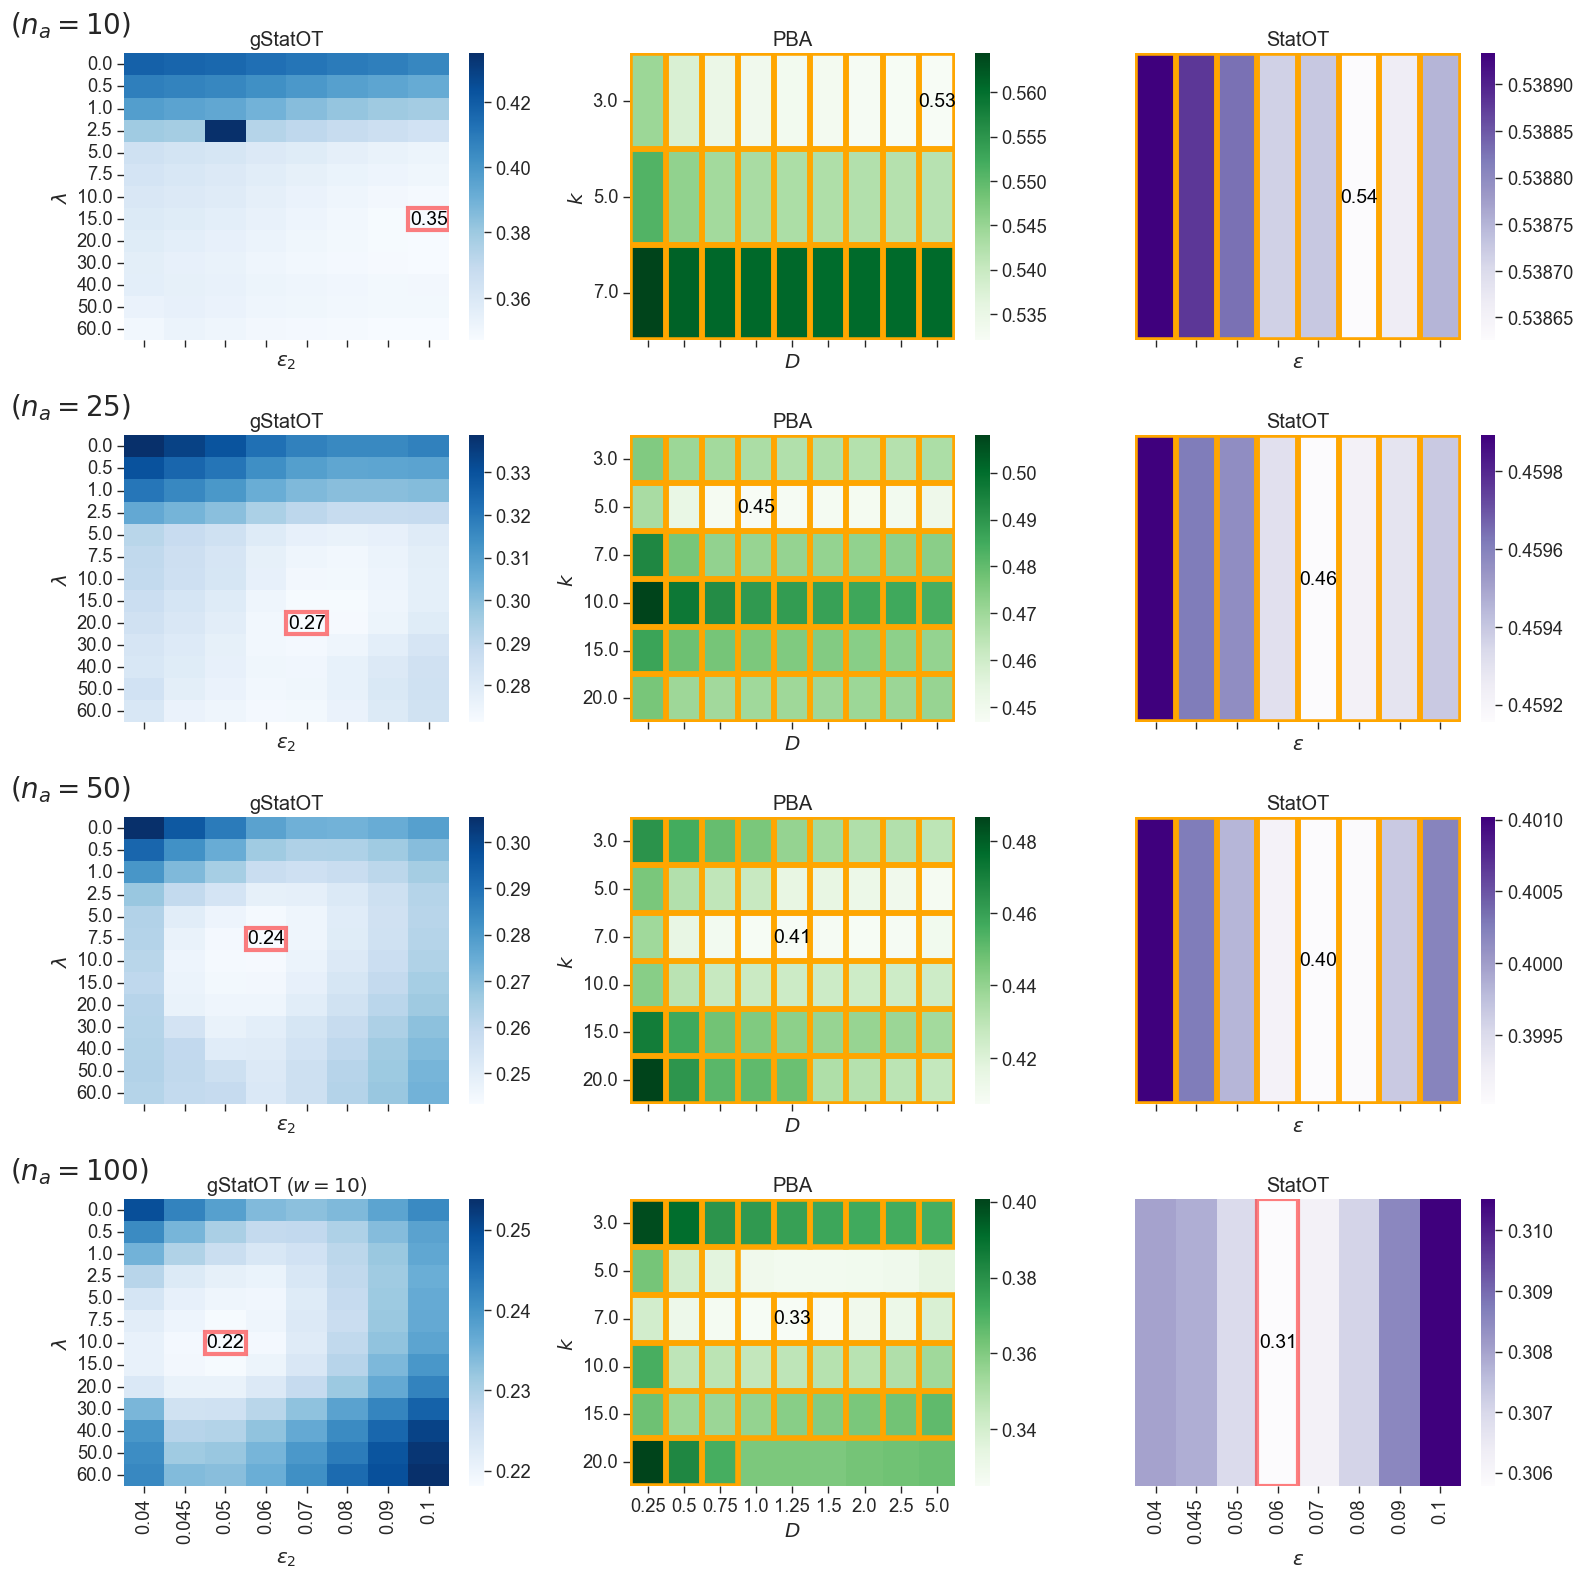

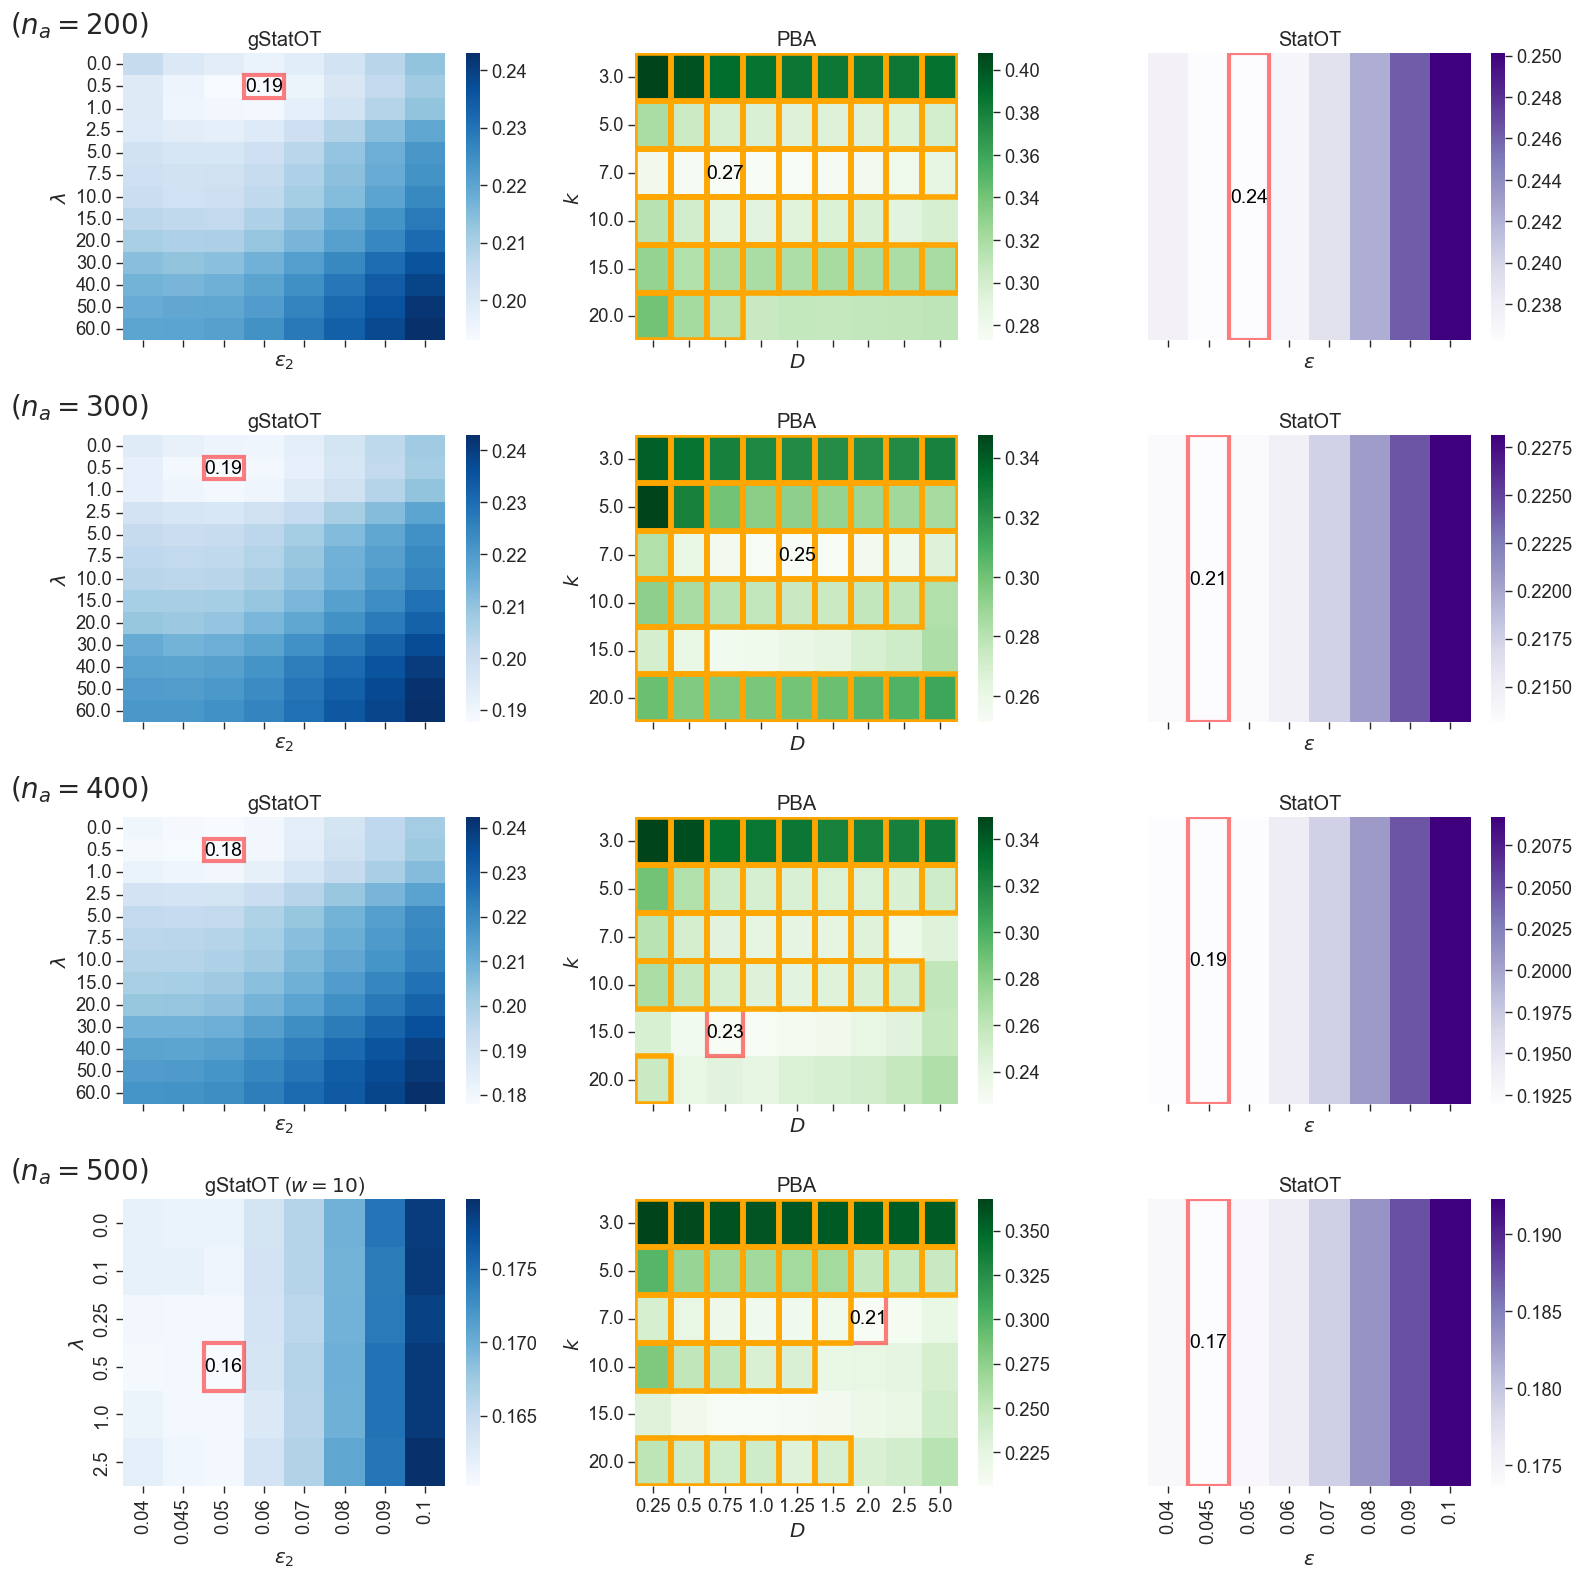

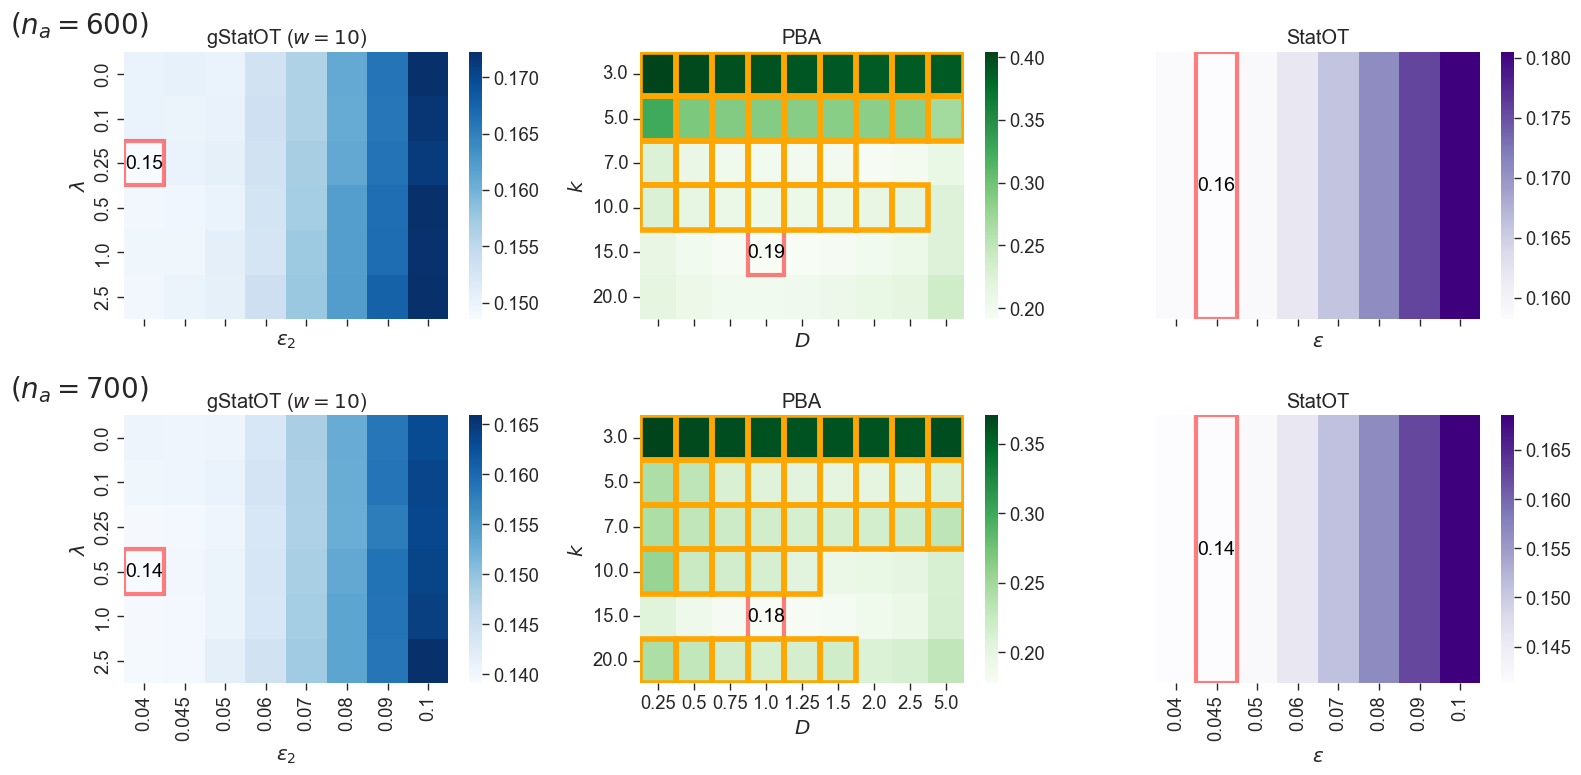

In [10]:
n_vals = post_res['n'].unique()
n_vals.sort()

gStatOT_opt_vals = {}
StatOT_opt_vals = {}
PBA_opt_vals = {}

fig, axs = plt.subplots(4, 3, figsize=(figsize * 4, figsize * 4), sharex='col', )
for i, n in enumerate(n_vals[:4]):

    res_n = post_res[post_res['n'] == n].copy()
    res_df_gStatOT = res_n[res_n['method'] == 'gStatOT']
    res_df_StatOT = res_n[res_n['method'] == 'StatOT']
    res_df_PBA = res_n[res_n['method'] == 'PBA']

    ax1 = axs[i, 0] 
    vmin = None
    vmax = None
    lam, epsilon2 = sweep_utils.plot_sweep_results(res_df_gStatOT, 'lam', 'epsilon2', 
                                         metric='mean_metric', title='gStatOT',  
                                         cbar=True,
                                         input_ax=ax1,
                                         vminmax=(vmin, vmax),
                                         highlight_nans=True,
                                         cmap=gsot_cmap)
    ax1.set_ylabel(r'$\lambda$')
    ax1.set_xlabel(r'$\epsilon_2$')
    if i == 3:
        ax1.set_title(rf'gStatOT ($w = 10$)')

    ax1.text(-0.35, 1.1, rf'$(n_a={n})$', transform=ax1.transAxes, fontsize=20, 
             fontweight='bold', va='center')

    gStatOT_opt_vals[n] = (lam, epsilon2)


    ax3 = axs[i, 2]
    _, epsilon = sweep_utils.plot_sweep_results(res_df_StatOT, None, 'epsilon',
                                         metric='mean_metric', title='StatOT',
                                         cbar=True,
                                         input_ax=ax3,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=sot_cmap)
    ax3.set_xlabel(r'$\epsilon$')
    ax3.set_ylabel('')
    ax3.set_yticks([])
    StatOT_opt_vals[n] = epsilon

    ax2 = axs[i, 1]
    k, D= sweep_utils.plot_sweep_results(res_df_PBA, 'k', 'D',
                                         metric='mean_metric', title='PBA',
                                         cbar=True,
                                         input_ax=ax2,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=pba_cmap)
    ax2.set_xlabel(r'$D$')
    ax2.set_ylabel(r'$k$')
    ax2.tick_params(axis='y', rotation=0)
    PBA_opt_vals[n] = (k, D)

plt.tight_layout()
plt.savefig(f'./sweep_res/final_figures/postnatal_results_n={n_vals[0]}-{n_vals[3]}.png', dpi=350)

fig, axs = plt.subplots(4, 3, figsize=(figsize * 4, figsize * 4), sharex='col')

for i, n in enumerate(n_vals[4: 8]):

    res_n = post_res[post_res['n'] == n].copy()
    vmin = None 
    vmax = None 
    res_df_gStatOT = res_n[res_n['method'] == 'gStatOT']
    res_df_StatOT = res_n[res_n['method'] == 'StatOT']
    res_df_PBA = res_n[res_n['method'] == 'PBA']

    ax1 = axs[i, 0] 
    lam, epsilon2 = sweep_utils.plot_sweep_results(res_df_gStatOT, 'lam', 'epsilon2', 
                                         metric='mean_metric', title='gStatOT',  
                                         cbar=True,
                                         input_ax=ax1,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=gsot_cmap)
    ax1.set_ylabel(r'$\lambda$')
    ax1.set_xlabel(r'$\epsilon_2$')
    if i == 3:
        ax1.set_title(rf'gStatOT ($w = 10$)')

    # add n as text to the left of the row
    ax1.text(-0.35, 1.1, rf'$(n_a={n})$', transform=ax1.transAxes, fontsize=20, 
             fontweight='bold', va='center')

    gStatOT_opt_vals[n] = (lam, epsilon2)


    ax3 = axs[i, 2]
    _, epsilon = sweep_utils.plot_sweep_results(res_df_StatOT, None, 'epsilon',
                                         metric='mean_metric', title='StatOT',
                                         cbar=True,
                                         input_ax=ax3,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=sot_cmap)
    ax3.set_xlabel(r'$\epsilon$')
    ax3.set_ylabel('')
    ax3.set_yticks([])
    StatOT_opt_vals[n] = epsilon

    ax2 = axs[i, 1]
    k, D= sweep_utils.plot_sweep_results(res_df_PBA, 'k', 'D',
                                         metric='mean_metric', title='PBA',
                                         cbar=True,
                                         input_ax=ax2,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=pba_cmap)
    ax2.set_xlabel(r'$D$')
    ax2.set_ylabel(r'$k$')
    ax2.tick_params(axis='y', rotation=0)
    PBA_opt_vals[n] = (k, D)

plt.tight_layout()
plt.savefig(f'./sweep_res/final_figures/postnatal_results_n={n_vals[4]}-{n_vals[8]}.png', dpi=350)


fig, axs = plt.subplots(2, 3, figsize=(figsize * 4, figsize * 2), sharex='col')

for i, n in enumerate(n_vals[8: ]):

    res_n = post_res[post_res['n'] == n].copy()
    vmin = None 
    vmax = None 
    res_df_gStatOT = res_n[res_n['method'] == 'gStatOT']
    res_df_StatOT = res_n[res_n['method'] == 'StatOT']
    res_df_PBA = res_n[res_n['method'] == 'PBA']

    ax1 = axs[i, 0] 
    lam, epsilon2 = sweep_utils.plot_sweep_results(res_df_gStatOT, 'lam', 'epsilon2', 
                                         metric='mean_metric', title='gStatOT',  
                                         cbar=True,
                                         input_ax=ax1,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=gsot_cmap)
    ax1.set_ylabel(r'$\lambda$')
    ax1.set_xlabel(r'$\epsilon_2$')
    ax1.set_title(rf'gStatOT ($w = 10$)')

    # add n as text to the left of the row
    ax1.text(-0.35, 1.1, rf'$(n_a={n})$', transform=ax1.transAxes, fontsize=20, 
             fontweight='bold', va='center')

    gStatOT_opt_vals[n] = (lam, epsilon2)


    ax3 = axs[i, 2]
    _, epsilon = sweep_utils.plot_sweep_results(res_df_StatOT, None, 'epsilon',
                                         metric='mean_metric', title='StatOT',
                                         cbar=True,
                                         input_ax=ax3,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=sot_cmap)
    ax3.set_xlabel(r'$\epsilon$')
    ax3.set_ylabel('')
    ax3.set_yticks([])
    StatOT_opt_vals[n] = epsilon

    ax2 = axs[i, 1]
    k, D= sweep_utils.plot_sweep_results(res_df_PBA, 'k', 'D',
                                         metric='mean_metric', title='PBA',
                                         cbar=True,
                                         input_ax=ax2,
                                         vminmax=(vmin, vmax), 
                                         highlight_nans=True,
                                         cmap=pba_cmap)
    ax2.set_xlabel(r'$D$')
    ax2.set_ylabel(r'$k$')
    ax2.tick_params(axis='y', rotation=0)
    PBA_opt_vals[n] = (k, D)

plt.tight_layout()
plt.savefig(f'./sweep_res/final_figures/postnatal_results_n={n_vals[8]}-{n_vals[-1]}.png', dpi=350)




plt.show()
gStatOT_opt_vals_df = pd.DataFrame(gStatOT_opt_vals, index=['lam', 'epsilon2']).T
StatOT_opt_vals_df = pd.DataFrame(StatOT_opt_vals, index=['epsilon']).T
PBA_opt_vals_df = pd.DataFrame(PBA_opt_vals, index=['k', 'D']).T

gStatOT_opt_vals_df.to_csv('./gStatOT_opt_vals_postnatal_n.csv')
StatOT_opt_vals_df.to_csv('./StatOT_opt_vals_postnatal_n.csv')
PBA_opt_vals_df.to_csv('./PBA_opt_vals_postnatal_n.csv')